# Naturalness Scores for double mutants

**Goal:** Evaluate different "double mutant naturalness" strategies.

**Background:** Many strategies exist in literature. (TODO: list some prior results). I want to try a few using ESMC-600M, and see how they work for myself.

**Approach:** For each single mutant of [SPG1](https://foldy.lbl.gov/fold/7617), I did a forward run through ESMC-600M. I'll first see how different strategies are correlated to activity with Spearman rho.

In [121]:
import pandas as pd
import dask.dataframe as dd


In [122]:
pg_df = pd.read_csv('notebooks/jacob/data/DMS_substitutions.csv')

In [123]:
spg_metadata = pg_df[pg_df['DMS_id'] == 'SPG1_STRSG_Olson_2014'].iloc[0]
spg_wt_seq = spg_metadata['target_seq']
spg_filepath = spg_metadata['DMS_filename']

spg_df = pd.read_csv(f'notebooks/jacob/data/DMS_ProteinGym_substitutions/{spg_filepath}')
spg_df['seq_id'] = spg_df.mutant.apply(lambda x: x.replace(':', '_'))
spg_df['first_mut'] = spg_df.seq_id.apply(lambda x: x.split('_')[0] if x.count('_') == 1 else pd.NA)
spg_df['second_mut'] = spg_df.seq_id.apply(lambda x: x.split('_')[1] if x.count('_') == 1 else pd.NA)
spg_df['first_mut_locus'] = spg_df.first_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
spg_df['second_mut_locus'] = spg_df.second_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
spg_df.drop(columns=['mutated_sequence'], inplace=True)
spg_df

,mutant,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus
0,Q228R:T279L,0.328504,1,Q228R_T279L,Q228R,T279L,228,279
1,Q228K:T279A,0.702656,1,Q228K_T279A,Q228K,T279A,228,279
2,Q228K:T279C,0.422857,1,Q228K_T279C,Q228K,T279C,228,279
3,Q228K:T279D,0.263417,1,Q228K_T279D,Q228K,T279D,228,279
4,Q228K:T279E,0.734820,1,Q228K_T279E,Q228K,T279E,228,279
...,...,...,...,...,...,...,...,...
536957,E282Q:T251Q,0.202574,1,E282Q_T251Q,E282Q,T251Q,282,251
536958,E282Q:T251P,-0.289294,1,E282Q_T251P,E282Q,T251P,282,251
536959,E282Q:T251N,-0.688549,1,E282Q_T251N,E282Q,T251N,282,251
536960,E282Q:T270E,-0.916291,1,E282Q_T270E,E282Q,T270E,282,270


<Axes: xlabel='None'>

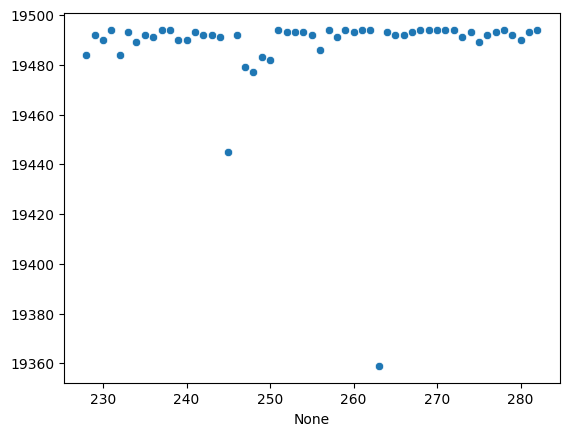

In [124]:
import seaborn as sns
spg_counts = pd.concat([
  spg_df.first_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA),
  spg_df.second_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
], ignore_index=True).value_counts()
sns.scatterplot(x=spg_counts.index, y=spg_counts.values)

In [32]:
raw_naturalness_dd = dd.read_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet")
raw_naturalness_dd['base_id_subseq_id'] = raw_naturalness_dd['base_seq_id'] + '_' + raw_naturalness_dd['seq_id']
raw_naturalness_dd.set_index('base_id_subseq_id', inplace=True)
raw_naturalness_dd = raw_naturalness_dd.drop(columns=['base_seq_id', 'seq_id'])
raw_naturalness_dd = raw_naturalness_dd.repartition(npartitions=20)
raw_naturalness_dd = raw_naturalness_dd.persist()

# raw_naturalness = pd.read_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet")


# from tqdm import tqdm

# raw_naturalness = pd.read_csv('notebooks/jacob/data/spg1_logits_600m_doubles_melted.csv')
# # Initialize an empty list to store the chunked dataframes
# dfs = []

# # Read the CSV file in chunks
# reader = pd.read_csv('notebooks/jacob/data/spg1_logits_600m_doubles_melted.csv', chunksize=10000)  # Adjust the chunksize as per your memory capacity

# # Iterate through each chunk and append it to the list
# for chunk in tqdm(reader):
#     dfs.append(chunk)

# # Concatenate all the chunks into a single dataframe
# raw_naturalness = pd.concat(dfs, ignore_index=True)

# raw_naturalness.to_parquet("notebooks/jacob/data/spg1_logits_600m_doubles_melted.parquet", engine="pyarrow")  # Fast, compressed storage

In [ ]:
base_naturalness_df = raw_naturalness_dd[raw_naturalness_dd['base_id_subseq_id'].str.startswith('WT')].compute()
base_naturalness_df['seq_id'] = base_naturalness_df['base_id_subseq_id'].apply(lambda x: x.split('_')[1])


In [64]:
wt_scores = base_naturalness_df[base_naturalness_df.seq_id.apply(lambda x: x[0] == x[-1])].copy()
wt_scores['locus'] = wt_scores.seq_id.apply(lambda x: int(x[1:-1]))
wt_scores.set_index('locus', inplace=True)
wt_scores = wt_scores[['probability']]
wt_scores.head()


,probability
locus,
1,1.000000
2,0.062256
3,0.302734
4,0.416016
5,0.449219


## First compute the linear model of naturalness.

In [86]:
import numpy as np
spg_df_plus = spg_df.copy()
spg_df_plus = pd.merge(
  spg_df_plus,
  base_naturalness_df.set_index('seq_id')[['probability']].rename(columns={'probability': 'second_mut_prob'}),
  left_on='second_mut',
  right_on='seq_id',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  base_naturalness_df.set_index('seq_id')[['probability']].rename(columns={'probability': 'first_mut_prob'}),
  left_on='first_mut',
  right_on='seq_id',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  wt_scores.rename(columns={'probability': 'first_mut_wt_prob'}),
  left_on='first_mut_locus',
  right_on='locus',
  how='left',
)
spg_df_plus = pd.merge(
  spg_df_plus,
  wt_scores.rename(columns={'probability': 'second_mut_wt_prob'}),
  left_on='second_mut_locus',
  right_on='locus',
  how='left',
)



In [87]:
import numpy as np

def compute_double_mutant_naturalness(row):
  if (row['first_mut_wt_prob'] is pd.NA or
      row['second_mut_wt_prob'] is pd.NA or
      row['first_mut_prob'] is pd.NA or
      row['second_mut_prob'] is pd.NA):
    return pd.NA
  score1 = row['first_mut_prob'] / row['first_mut_wt_prob']
  score2 = row['second_mut_prob'] / row['second_mut_wt_prob']
  return score1 * score2

spg_df_plus['double_mutant_naturalness'] = spg_df_plus.apply(compute_double_mutant_naturalness, axis=1)
spg_df_plus['log_double_mutant_naturalness'] = np.log(spg_df_plus['double_mutant_naturalness'])
spg_df_plus.head()


,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,second_mut_prob,first_mut_prob,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,log_double_mutant_naturalness
0,Q228R:T279L,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.328504,1,Q228R_T279L,Q228R,T279L,228,279,0.000324,0.003235,0.00824,0.964844,0.000132,-8.933192
1,Q228K:T279A,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.702656,1,Q228K_T279A,Q228K,T279A,228,279,0.002121,0.069336,0.00824,0.964844,0.018498,-3.990098
2,Q228K:T279C,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.422857,1,Q228K_T279C,Q228K,T279C,228,279,0.000006,0.069336,0.00824,0.964844,0.000049,-9.931788
3,Q228K:T279D,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.263417,1,Q228K_T279D,Q228K,T279D,228,279,0.000324,0.069336,0.00824,0.964844,0.002828,-5.868215
4,Q228K:T279E,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.734820,1,Q228K_T279E,Q228K,T279E,228,279,0.001129,0.069336,0.00824,0.964844,0.009848,-4.620507


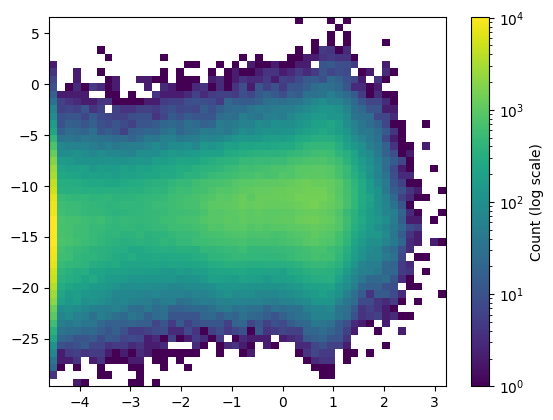

In [89]:
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

# hist = plt.hexbin(spg_df['DMS_score'], spg_df['log_double_mutant_naturalness'], gridsize=50, cmap='viridis', mincnt=1, norm=LogNorm())
hist = plt.hist2d(spg_df_plus.dropna()['DMS_score'], spg_df_plus.dropna()['log_double_mutant_naturalness'], bins=50, cmap='viridis', norm=LogNorm())

plt.colorbar(hist[3], label='Count (log scale)')
# sns.scatterplot(x='DMS_score', y='double_mutant_naturalness', data=spg_df)
# plt.yscale('log')

In [90]:
# Compute the correlation between DMS_score and log_double_mutant_naturalness
corr = spg_df_plus.dropna()[['DMS_score', 'log_double_mutant_naturalness']].corr(method='spearman')
print(f"Correlation: {corr.iloc[0, 1]:.2f}")


Correlation: 0.27


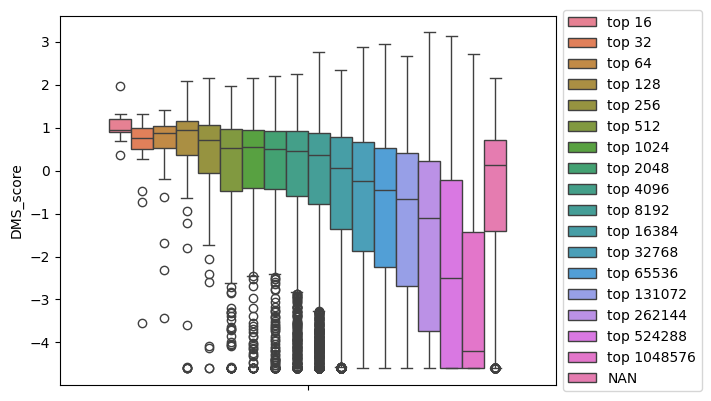

In [91]:
# Show the boxplot of DMS scores for the top 16, 32, 64, 128 mutants
def rank_to_category(rank):
  if pd.isna(rank):
    return 'NAN'
  cutoff = 16
  while rank > cutoff:
    cutoff *= 2
  return f'top {cutoff}'
spg_df_plus.sort_values(by='double_mutant_naturalness', ascending=False, inplace=True)
spg_df_plus['naturalness_category'] = spg_df_plus['double_mutant_naturalness'].rank(ascending=False).apply(rank_to_category)
sns.boxplot(hue='naturalness_category', y='DMS_score', data=spg_df_plus)
# Put legend on right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


> Ok that went surprisingly well. But note that the top ranked performers all have poor naturalness scores.

# More advanced scores

In [95]:
spg_df_with_pairs = spg_df.copy()
spg_df_with_pairs = spg_df_with_pairs.dropna()
spg_df_with_pairs['first_then_second'] = spg_df_with_pairs.apply(lambda row: row['first_mut'] + '_' + row['second_mut'], axis=1)
spg_df_with_pairs.set_index('first_then_second', inplace=True)

In [96]:
# spg_df_with_second_in_first = raw_naturalness_dd.merge(
#   spg_df,
#   left_on=('base_seq_id', 'seq_id'),
#   right_on=('first_mut', 'second_mut'),
#   how='right'
# ).compute()

spg_df_with_pairs = raw_naturalness_dd.merge(
  spg_df_with_pairs,
  left_on='base_id_subseq_id',
  right_on='first_then_second',
  how='right'
).compute()

# second_in_first = raw_naturalness_dd[
#   (raw_naturalness_dd.base_seq_id == spg_df.dropna().first_mut) &
#   (raw_naturalness_dd.seq_id == spg_df.dropna().second_mut)
# ].compute()

In [97]:
spg_df_with_pairs['second_then_first'] = spg_df_with_pairs.apply(lambda row: row['second_mut'] + '_' + row['first_mut'], axis=1)
spg_df_with_pairs.set_index('second_then_first', inplace=True)

In [98]:

spg_df_with_pairs = raw_naturalness_dd.merge(
  spg_df_with_pairs,
  left_on='base_id_subseq_id',
  right_on='second_then_first',
  how='right',
  suffixes=('_first_then_second', '_second_then_first')
).compute()

In [99]:
spg_df_with_pairs.head()

,probability_first_then_second,base_id_subseq_id_first_then_second,probability_second_then_first,base_id_subseq_id_second_then_first,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus
0,0.011475,A249C_A246G,0.000019,A246G_A249C,A246G:A249C,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,-0.826679,1,A246G_A249C,A246G,A249C,246,249
1,0.035400,A249C_A246L,0.000017,A246L_A249C,A246L:A249C,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,-1.432575,1,A246L_A249C,A246L,A249C,246,249
2,0.006805,A249D_A246R,0.003998,A246R_A249D,A246R:A249D,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.526213,1,A246R_A249D,A246R,A249D,246,249
3,0.008240,A249F_A246N,0.001945,A246N_A249F,A246N:A249F,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,-4.595120,0,A246N_A249F,A246N,A249F,246,249
4,0.003891,A249F_A246Y,0.002380,A246Y_A249F,A246Y:A249F,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,-4.605170,0,A246Y_A249F,A246Y,A249F,246,249


In [108]:
spg_df_with_pairs.drop(columns=['first_mut_wt_prob_x', 'second_mut_wt_prob_x', 'first_mut_wt_prob_y', 'second_mut_wt_prob_y'], inplace=True)

In [109]:
spg_df_with_pairs['first_mut_locus'] = spg_df_with_pairs.first_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)
spg_df_with_pairs['second_mut_locus'] = spg_df_with_pairs.second_mut.apply(lambda x: int(x[1:-1]) if x is not pd.NA else pd.NA)

spg_df_with_pairs = pd.merge(
  spg_df_with_pairs,
  wt_scores.rename(columns={'probability': 'first_mut_wt_prob'}),
  left_on='first_mut_locus',
  right_on='locus',
  how='left',
)
spg_df_with_pairs = pd.merge(
  spg_df_with_pairs,
  wt_scores.rename(columns={'probability': 'second_mut_wt_prob'}),
  left_on='second_mut_locus',
  right_on='locus',
  how='left',
)

In [110]:
spg_df_with_pairs['double_mutant_naturalness'] = spg_df_with_pairs.apply(lambda row: (
  row['probability_first_then_second'] * row['probability_second_then_first'] / (row['first_mut_wt_prob'] * row['second_mut_wt_prob'])
), axis=1)

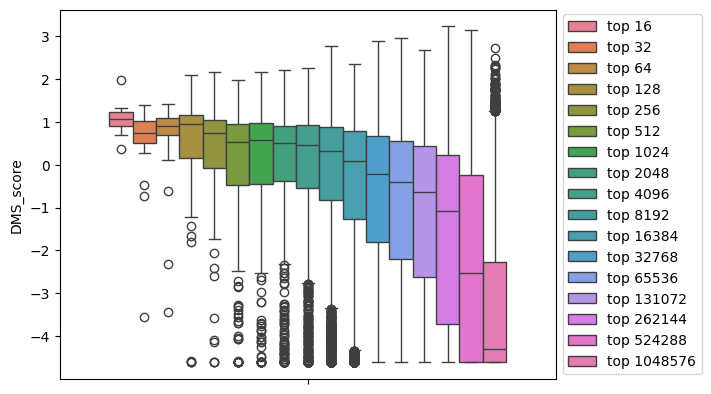

In [111]:
from matplotlib import pyplot as plt
# Show the boxplot of DMS scores for the top 16, 32, 64, 128 mutants
def rank_to_category(rank):
  if pd.isna(rank):
    return 'NAN'
  cutoff = 16
  while rank > cutoff:
    cutoff *= 2
  return f'top {cutoff}'
spg_df_with_pairs.sort_values(by='double_mutant_naturalness', ascending=False, inplace=True)
spg_df_with_pairs['naturalness_category'] = spg_df_with_pairs['double_mutant_naturalness'].rank(ascending=False).apply(rank_to_category)
sns.boxplot(hue='naturalness_category', y='DMS_score', data=spg_df_with_pairs)
# Put legend on right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


## Compare the two

In [94]:
spg_df_plus.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,second_mut_prob,first_mut_prob,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,log_double_mutant_naturalness,naturalness_category
33235,I232V:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.367725,1,I232V_Q228T,I232V,Q228T,232,228,0.742188,0.828125,0.099121,0.008240,752.540047,6.623454,top 16
44375,L233I:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.298696,1,L233I_Q228T,L233I,Q228T,233,228,0.742188,0.652344,0.127930,0.008240,459.309019,6.129723,top 16
3481,Q228T:V255A,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.963544,1,Q228T_V255A,Q228T,V255A,228,255,0.753906,0.742188,0.008240,0.167969,404.285960,6.002122,top 16
158390,E245K:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.146960,1,E245K_Q228T,E245K,Q228T,245,228,0.742188,0.671875,0.193359,0.008240,312.984661,5.746154,top 16
415173,E268V:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.321427,1,E268V_Q228T,E268V,Q228T,268,228,0.742188,0.554688,0.296875,0.008240,168.296296,5.125726,top 16


In [112]:
spg_df_with_pairs.head()

,probability_first_then_second,base_id_subseq_id_first_then_second,probability_second_then_first,base_id_subseq_id_second_then_first,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id,first_mut,second_mut,first_mut_locus,second_mut_locus,first_mut_wt_prob,second_mut_wt_prob,double_mutant_naturalness,naturalness_category
466533,0.835938,Q228T_I232V,0.734375,I232V_Q228T,I232V:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.367725,1,I232V_Q228T,I232V,Q228T,232,228,0.099121,0.008240,751.643277,top 16
144909,0.652344,Q228T_L233I,0.734375,L233I_Q228T,L233I:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.298696,1,L233I_Q228T,L233I,Q228T,233,228,0.127930,0.008240,454.474187,top 16
100685,0.757812,V255A_Q228T,0.750000,Q228T_V255A,Q228T:V255A,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,0.963544,1,Q228T_V255A,Q228T,V255A,228,255,0.008240,0.167969,410.658398,top 16
332527,0.640625,Q228T_E245K,0.742188,E245K_Q228T,E245K:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.146960,1,E245K_Q228T,E245K,Q228T,245,228,0.193359,0.008240,298.427235,top 16
171531,0.546875,Q228T_E268V,0.757812,E268V_Q228T,E268V:Q228T,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,1.321427,1,E268V_Q228T,E268V,Q228T,268,228,0.296875,0.008240,169.419103,top 16


Text(0, 0.5, 'Pairwise model for epistasis (expensive to compute)')

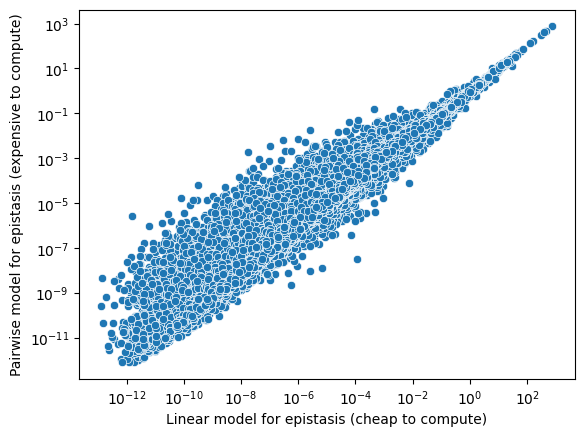

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

mutant_list = spg_df_plus['mutant'].tolist()
mutant_list = [m for m in mutant_list if ':' in m]
sns.scatterplot(
  x=spg_df_plus.set_index('mutant')['double_mutant_naturalness'][mutant_list],
  y=spg_df_with_pairs.set_index('mutant')['double_mutant_naturalness'][mutant_list]
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Linear model for epistasis (cheap to compute)')
plt.ylabel('Pairwise model for epistasis (expensive to compute)')


In [115]:
mutant_list

33235     I232V:Q228T
44375     L233I:Q228T
3481      Q228T:V255A
158390    E245K:Q228T
415173    E268V:Q228T
             ...     
533505          E282P
534522          E282N
535740          E282S
536342          E282Q
536648          E282R
Name: mutant, Length: 536962, dtype: object